In [1]:
%cd

/home/ajoshi83


/home/ajoshi83/.conda/envs/amj/lib/python3.11/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/ajoshi83/.conda/envs/amj/lib/python3.11/site-packages/IPython/core/magics/osm.py:428: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import logging
import os
import sys
from pathlib import Path
import pandas as pd
import monai
import argparse
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader as _TorchDataLoader
from torch.utils.data import Dataset
from torch.utils.tensorboard import SummaryWriter

from monai.data import decollate_batch, CSVSaver, DataLoader
from monai.data.utils import list_data_collate, set_rnd, worker_init_fn
from monai.metrics import ROCAUCMetric
from monai.transforms import ScaleIntensityRanged, NormalizeIntensityd, Activations, AsDiscrete, Compose, LoadImaged, RandRotated, Resized, ScaleIntensityd, RandFlipd
from monai.networks.nets import resnet10, resnet18, resnet34, resnet50

from sklearn.model_selection import StratifiedKFold
from statistics import mean, mode
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, roc_auc_score

/home/ajoshi83/.local/lib/python3.11/site-packages/ignite/handlers/checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer
IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Error importing huggingface_hub.file_download: No module named 'yaml'


In [3]:
def calculate_scores(y_true, y_pred_act_all):
    print("="*20)
    print("Test Set Results:\n")
    y_pred_act_all = np.array(y_pred_act_all)
    sum5 = np.sum(np.array(y_pred_act_all), axis=0)
    probs = sum5/5
    ypred_soft_votes = np.argmax(probs, axis=1)
    acc_score = accuracy_score(y_true, ypred_soft_votes)

    probs_auc = y_pred_act_all[:,:,1]
    sum5 = np.sum(np.array(probs_auc), axis=0)
    probs_auc = sum5/5
    auc_score = roc_auc_score(y_true, probs_auc)

    cm = confusion_matrix(y_true, ypred_soft_votes)
    # Calculate confusion matrix
    tn, fp, fn, tp = cm.ravel()

    # Calculate Precision
    precision = precision_score(y_true, ypred_soft_votes)

    # Calculate Recall (Sensitivity)
    recall = recall_score(y_true, ypred_soft_votes)

    # Calculate Specificity
    specificity = tn / (tn + fp)

    # Calculate F1 Score
    f1 = f1_score(y_true, ypred_soft_votes)
    return acc_score, auc_score, precision, recall, specificity, f1, cm, ypred_soft_votes

MONAI version: 1.3.2
Numpy version: 1.26.4
Pytorch version: 2.4.0+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 59a7211070538586369afd4a01eca0a7fe2e742e
MONAI __file__: /home/<username>/.local/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.0
Nibabel version: 5.2.1
scikit-image version: 0.24.0
scipy version: 1.11.4
Pillow version: 10.4.0
Tensorboard version: 2.17.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.0+cu121
tqdm version: 4.66.5
lmdb version: 1.5.1
psutil version: 5.9.0
pandas version: 2.2.2
einops version: 0.8.0
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: 1.0.0
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-reco

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. W

Test Set Results:

Accuracy: 0.6765
AUC Score: 0.7107
Precision: 0.6667
Recall (Sensitivity): 0.9
Specificity: 0.3571
F1 Score: 0.766
              precision    recall  f1-score   support

   class 0+1       0.71      0.36      0.48        14
     class 2       0.67      0.90      0.77        20

    accuracy                           0.68        34
   macro avg       0.69      0.63      0.62        34
weighted avg       0.69      0.68      0.65        34



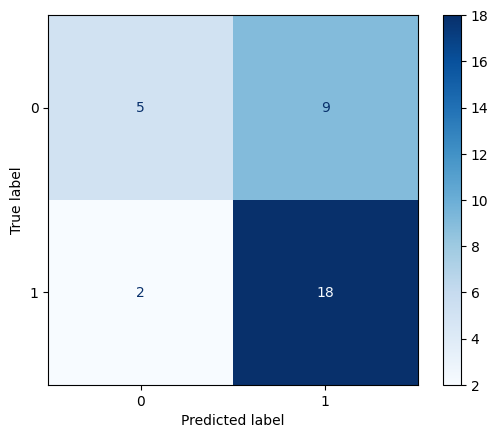

In [4]:
import sys
from mri_classification.scripts.sbatch.bi_5fold_ensemble_eval import main
from scipy.stats import mode
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


sys.argv = ['']

parser = argparse.ArgumentParser()

parser.add_argument('--ct_type', type=str, default='Fake')
parser.add_argument('--mr_type', type=str, default='Real')

parser.add_argument('--opt', type=str, default='Adam')
parser.add_argument('--epochs', type=int, default=60)
parser.add_argument('--lr', type=float, default=1e-5)
parser.add_argument('--wdecay', type=float, default=1e-3)
    
config = parser.parse_args()

y_true, y_pred_act_all = main(config)

acc_score, auc_score, precision, recall, specificity, f1, cm, ypred_soft_votes = calculate_scores(y_true, y_pred_act_all)

# Print the results
print(f"Accuracy: {round(acc_score, 4)}")
print(f"AUC Score: {round(auc_score, 4)}")
print(f"Precision: {round(precision,4)}")
print(f"Recall (Sensitivity): {round(recall,4)}")
print(f"Specificity: {round(specificity, 4)}")
print(f"F1 Score: {round(f1, 4)}")

target_names = ['class 0+1', 'class 2']

print(classification_report(y_true, ypred_soft_votes, target_names=target_names))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.show()

MONAI version: 1.3.2
Numpy version: 1.26.4
Pytorch version: 2.4.0+cu121
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: 59a7211070538586369afd4a01eca0a7fe2e742e
MONAI __file__: /home/<username>/.local/lib/python3.11/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: 0.4.11
ITK version: 5.4.0
Nibabel version: 5.2.1
scikit-image version: 0.24.0
scipy version: 1.11.4
Pillow version: 10.4.0
Tensorboard version: 2.17.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.19.0+cu121
tqdm version: 4.66.5
lmdb version: 1.5.1
psutil version: 5.9.0
pandas version: 2.2.2
einops version: 0.8.0
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: 1.0.0
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/latest/installation.html#installing-the-reco

This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 1, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. W

Test Set Results:

Accuracy: 0.6765
AUC Score: 0.7286
Precision: 0.6667
Recall (Sensitivity): 0.9
Specificity: 0.3571
F1 Score: 0.766
              precision    recall  f1-score   support

   class 0+1       0.71      0.36      0.48        14
     class 2       0.67      0.90      0.77        20

    accuracy                           0.68        34
   macro avg       0.69      0.63      0.62        34
weighted avg       0.69      0.68      0.65        34



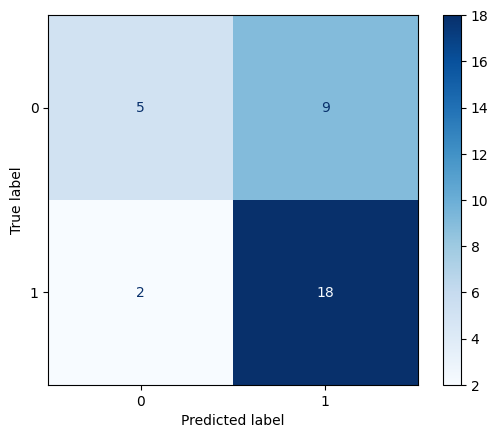

In [5]:
import sys
from mri_classification.scripts.sbatch.bi_5fold_ensemble_eval import main
from scipy.stats import mode
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score


sys.argv = ['']

parser = argparse.ArgumentParser()

parser.add_argument('--ct_type', type=str, default='Fake')
parser.add_argument('--mr_type', type=str, default='Real')

parser.add_argument('--opt', type=str, default='Adam')
parser.add_argument('--epochs', type=int, default=60)
parser.add_argument('--lr', type=float, default=1e-5)
parser.add_argument('--wdecay', type=float, default=1e-6)
    
config = parser.parse_args()

y_true, y_pred_act_all = main(config)

acc_score, auc_score, precision, recall, specificity, f1, cm, ypred_soft_votes = calculate_scores(y_true, y_pred_act_all)

# Print the results
print(f"Accuracy: {round(acc_score, 4)}")
print(f"AUC Score: {round(auc_score, 4)}")
print(f"Precision: {round(precision,4)}")
print(f"Recall (Sensitivity): {round(recall,4)}")
print(f"Specificity: {round(specificity, 4)}")
print(f"F1 Score: {round(f1, 4)}")

target_names = ['class 0+1', 'class 2']

print(classification_report(y_true, ypred_soft_votes, target_names=target_names))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = 'Blues')
plt.show()